In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/cleaned_retail.csv")

In [2]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [3]:
#Snapshot date
snapshot_date = df["InvoiceDate"].max()
print(snapshot_date)

2010-12-09 20:01:00


In [4]:
# RFM TABLE
rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "Revenue": "sum"
})

In [5]:
rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

In [6]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,164,11,372.86
12347.0,2,2,1323.32
12348.0,73,1,222.16
12349.0,42,3,2671.14
12351.0,10,1,300.93


In [7]:
rfm.describe()

,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000
mean,90.171846,4.455705,2040.406712
std,96.860633,8.170213,8911.755977
min,0.000000,1.000000,2.950000
25%,17.000000,1.000000,307.187500
50%,52.000000,2.000000,701.615000
75%,135.000000,5.000000,1714.932500
max,373.000000,205.000000,349164.350000


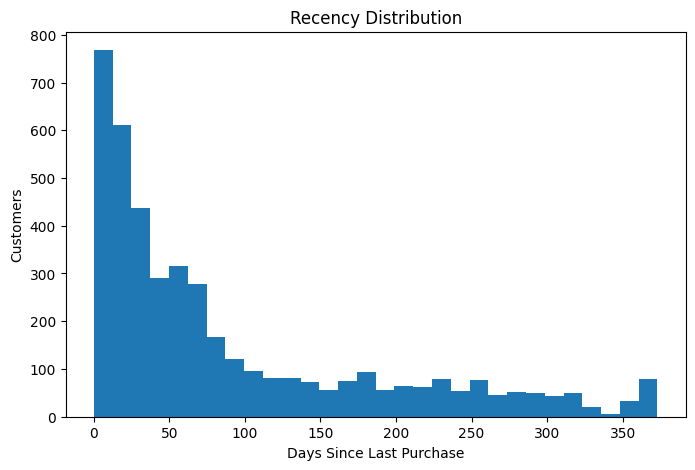

In [8]:
# Recency Distribution
plt.figure(figsize=(8,5))
plt.hist(rfm["Recency"], bins=30)

plt.title("Recency Distribution")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Customers")

plt.show()

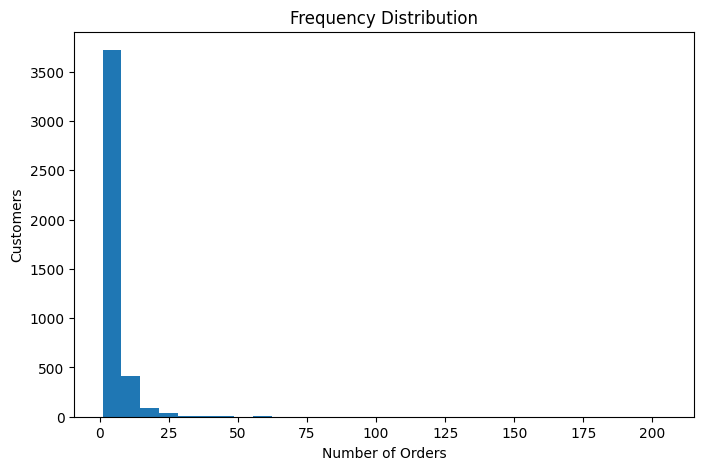

In [9]:
# Frequency Distribution
plt.figure(figsize=(8,5))
plt.hist(rfm["Frequency"], bins=30)

plt.title("Frequency Distribution")
plt.xlabel("Number of Orders")
plt.ylabel("Customers")

plt.show()

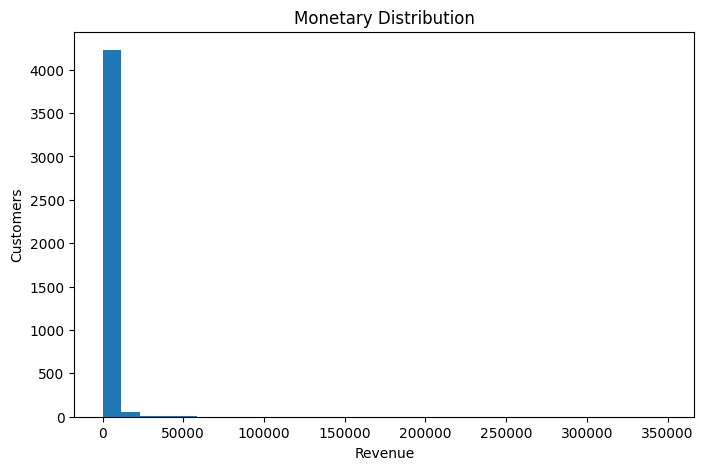

In [10]:
# Monetary Distribution
plt.figure(figsize=(8,5))
plt.hist(rfm["Monetary"], bins=30)

plt.title("Monetary Distribution")
plt.xlabel("Revenue")
plt.ylabel("Customers")

plt.show()

In [11]:
# creating recency score
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    4,
    labels=[4,3,2,1]
)

In [12]:
# frequency score
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    4,
    labels=[1,2,3,4]
)

In [13]:
# monetary score
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    4,
    labels=[1,2,3,4]
)

In [14]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
Customer ID,,,,,,
12346.0,164,11,372.86,1,4,2
12347.0,2,2,1323.32,4,2,3
12348.0,73,1,222.16,2,1,1
12349.0,42,3,2671.14,3,3,4
12351.0,10,1,300.93,4,1,1


In [15]:
# combined scores
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
12346.0,164,11,372.86,1,4,2,142
12347.0,2,2,1323.32,4,2,3,423
12348.0,73,1,222.16,2,1,1,211
12349.0,42,3,2671.14,3,3,4,334
12351.0,10,1,300.93,4,1,1,411


In [16]:
# customer segments
def customer_segment(row):

    if row["RFM_Score"] == "444":
        return "Champions"

    elif int(row["R_Score"]) >= 3 and int(row["F_Score"]) >= 3:
        return "Loyal Customers"

    elif int(row["R_Score"]) >= 3:
        return "Potential Loyalists"

    else:
        return "At Risk"

In [17]:
rfm["Segment"] = rfm.apply(
    customer_segment,
    axis=1
)

In [18]:
rfm["Segment"].value_counts()

Segment
At Risk                2122
Loyal Customers        1014
Potential Loyalists     719
Champions               457
Name: count, dtype: int64

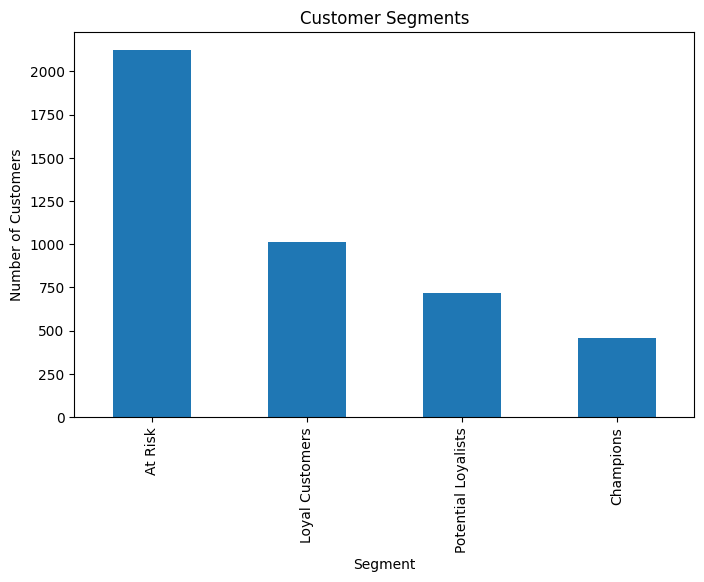

In [19]:
# visualize segments
rfm["Segment"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.show()

In [20]:
# Revenue by segment
segment_revenue = (
    rfm.groupby("Segment")["Monetary"]
       .sum()
       .sort_values(ascending=False)
)

segment_revenue

Segment
Champions              4463151.853
Loyal Customers        2007914.226
At Risk                1960655.585
Potential Loyalists     366512.080
Name: Monetary, dtype: float64

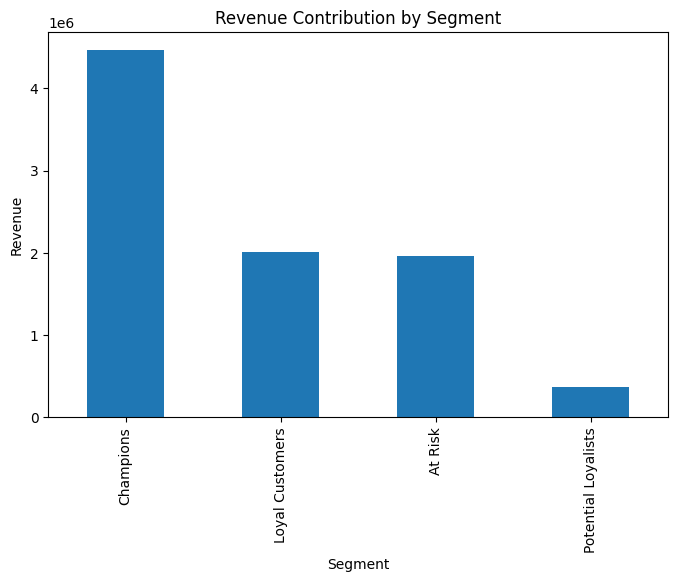

In [21]:
segment_revenue.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Revenue Contribution by Segment")
plt.ylabel("Revenue")

plt.show()

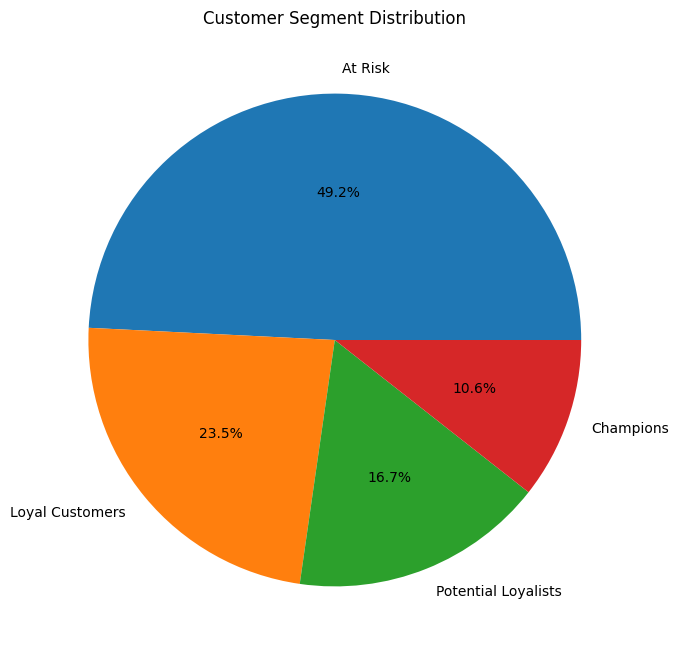

In [22]:
rfm["Segment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(8,8)
)

plt.title("Customer Segment Distribution")
plt.ylabel("")
plt.show()

# RFM Analysis Insights

1. The largest customer segment is At Risk, containing 2,122 customers.

2. Champions represent only 457 customers but contribute approximately 4.46 million in revenue.

3. Champions generate more than 50% of total revenue despite being a small portion of customers.

4. Loyal Customers contribute around 2 million in revenue and should be targeted for retention programs.

5. At Risk customers contribute significant revenue and present an opportunity for re-engagement campaigns.

6. Potential Loyalists can be nurtured into Loyal Customers through personalized offers and promotions.

In [23]:
rfm.to_csv(
    "../data/rfm_customers.csv"
)